In [1]:
import os
import copy
import torch
from pathlib import Path
from stCCL.stCCL.config import set_arg
from stCCL.stCCL.data import *
from stCCL.stCCL.utils import *
from stCCL.stCCL.stCCL import *
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/DLPFC')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/"
# result_path = "/home/ZHX/code111/GraphST-main/results/MVInfoNCE2_result/DLPFC/no_refine/"
#设置参数
opt = set_arg()
arg = opt.parse_args(['--epoch','1000','--n_domain', '7'])
print(arg)

当前路径： /home/ZHX/code111/GraphST-main/stCCL/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=64, log_step=10, lr=0.001, n_domain=7, n_refine=25, radius=150, seed=0, temp=0.05, weight_decay=0.0001)


In [3]:
# slice_idx = ['151507', '151508', '151509', '151510',
#              '151669', '151670', '151671', '151672',
#              '151673', '151674', '151675', '151676']
slice_idx = ['151673']
# slice_idx = ['151676']
adata_list_raw=[]
adata_list_after_training=[]
adata_list_after_clustering = []
results = []

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151673切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151673切片信息===============
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3639, 3000)
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  0%|          | 0/1000 [00:00<?, ?it/s]

 epoch:  0  feat_loss = 1.00  loss_sl_1 = 10.80  loss_sl_2 = 0.06  total_loss = 3.18


 11%|█         | 109/1000 [00:01<00:10, 84.86it/s]

...

 81%|████████  | 811/1000 [00:09<00:02, 85.68it/s]

 epoch:  800  feat_loss = 0.14  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.16


 91%|█████████ | 910/1000 [00:10<00:01, 85.65it/s]

 epoch:  900  feat_loss = 0.14  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.15


100%|██████████| 1000/1000 [00:11<00:00, 84.16it/s]


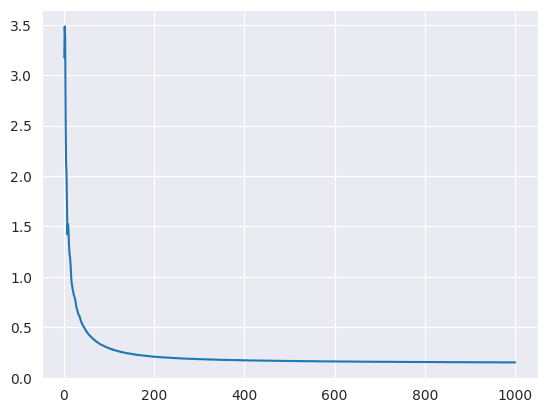

Completion of training


sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151673: 0.6309972207876174, 0.7380078998539996, 0.7585207391177207, 0.7185753133196501


/tmp/ipykernel_1634042/3181928122.py:44: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI


[{'slice_id': '151673', 'ARI': 0.6309972207876174, 'NMI': 0.7380078998539996, 'HS': 0.7585207391177207, 'CS': 0.7185753133196501}]


In [4]:


for sample_name in slice_idx:
    arg.n_domain = 5 if sample_name in ['151669', '151670', '151671', '151672'] else 7
    ## loading data
    adata = read_data(data_root, sample_name)

    ## add ground truth
    df_meta = pd.read_csv(data_root / sample_name / 'metadata.tsv', sep='\t')
    adata.obs['Ground Truth'] = df_meta['layer_guess']

    adata_list_raw.append(copy.deepcopy(adata)) ## 创建一个adata的深层副本并添加到列表中
    print("=============原始{}切片信息，带ground truth===============".format(sample_name))
    print(adata)

    #preprocessing
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=arg.hvg_n)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    print("=============预处理后{}切片信息===============".format(sample_name))
    print(adata)


    # train model
    adata = train(adata,arg)
    print("Completion of training")
    adata_list_after_training.append(adata)
    #
    #
    # clustering
    # adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' )
    # adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' ,refine=False)
    adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' ,refine=True)
#
    # filter out NA nodes
    adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
    ARI = adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground Truth'])
    NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs['Ground Truth'])
    HS = homogeneity_score(adata.obs['Ground Truth'],adata.obs['mclust'])
    CS = completeness_score(adata.obs['Ground Truth'],adata.obs['mclust'])

    print(f"ARI and NMI for slice {sample_name}: {ARI}, {NMI}, {HS}, {CS}")
    results.append({'slice_id': sample_name, 'ARI': ARI, 'NMI': NMI, 'HS': HS,'CS': CS})
    # print('ARI = %.4f' %ARI)
    # result_ARI.append(ARI)
    adata.uns['ARI']=ARI
    adata.uns['NMI']=NMI
    adata.uns['HS']=HS
    adata.uns['CS']=CS

    adata_list_after_clustering.append(adata)
#
print(results)

#
# result_ARI.append(average_ARI)
# results_df = pd.DataFrame(result_ARI)
# results_df.to_csv(os.path.join(result_path,'MM_shared_MVInfoNCE_test1_DLPFC_ARI.csv'))


In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置 scanpy 绘图参数（可选）
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

# 运行差异表达检验（这里用 Wilcoxon，也可用 t-test 或 logistic）
# use_raw=True 表示使用原始计数（若已存储），否则使用 .X（对数归一化）
sc.tl.rank_genes_groups(adata, groupby='mclust', method='wilcoxon', use_raw=False, rankby_abs=True)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=50
    finished (0:00:25)
Storing dendrogram info using `.uns['dendrogram_mclust']`


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


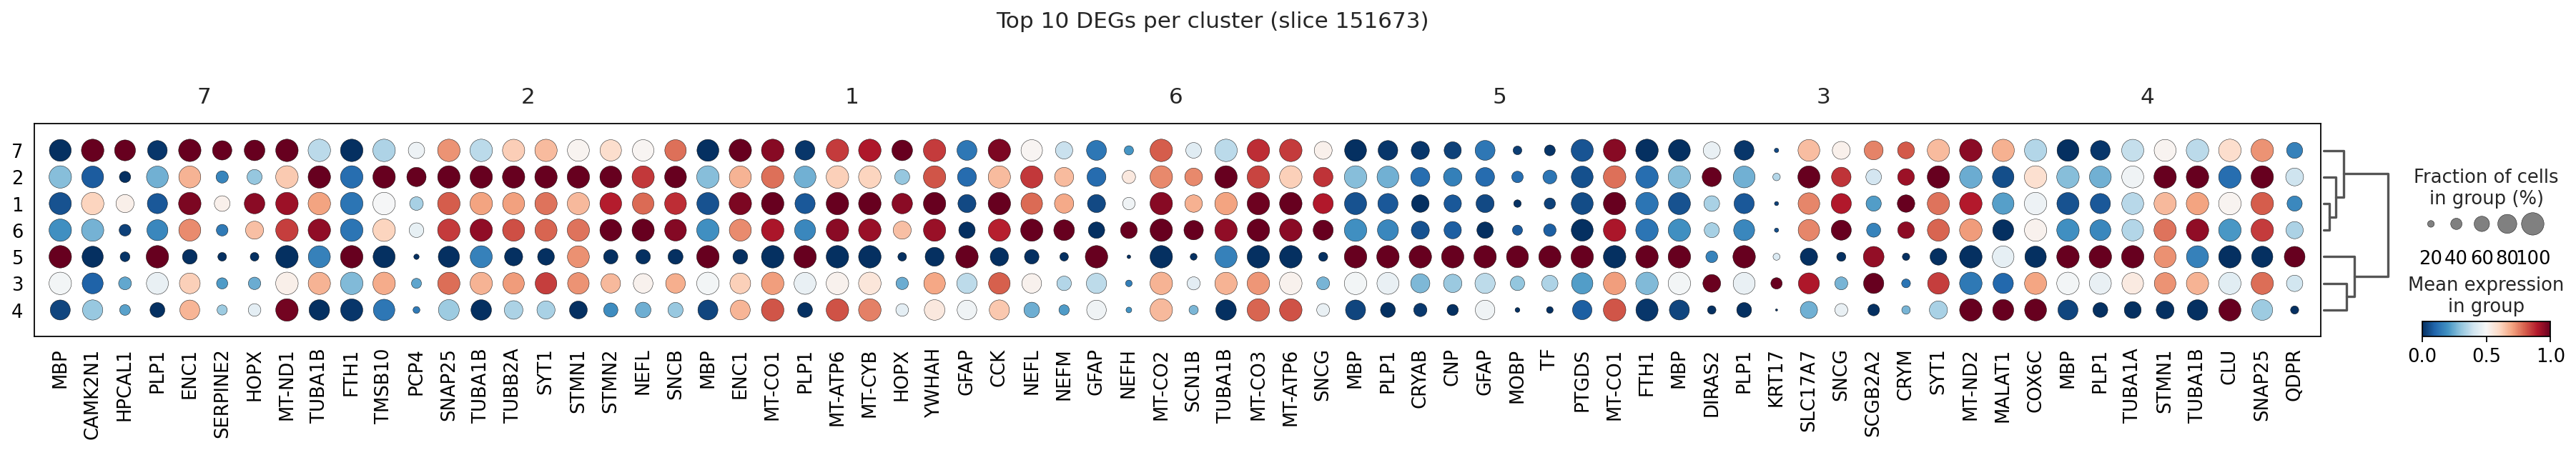

In [6]:
# 每个簇取前 10 个基因（也可调整 n_genes 参数）
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=10,
    groupby='mclust',
    standard_scale='var',      # 对基因表达做标准化，便于比较
    cmap='RdBu_r',
    title='Top 10 DEGs per cluster (slice 151673)',
    save='_F_dotplot.png'      # 保存为文件，若不需要可去掉
)
plt.show()

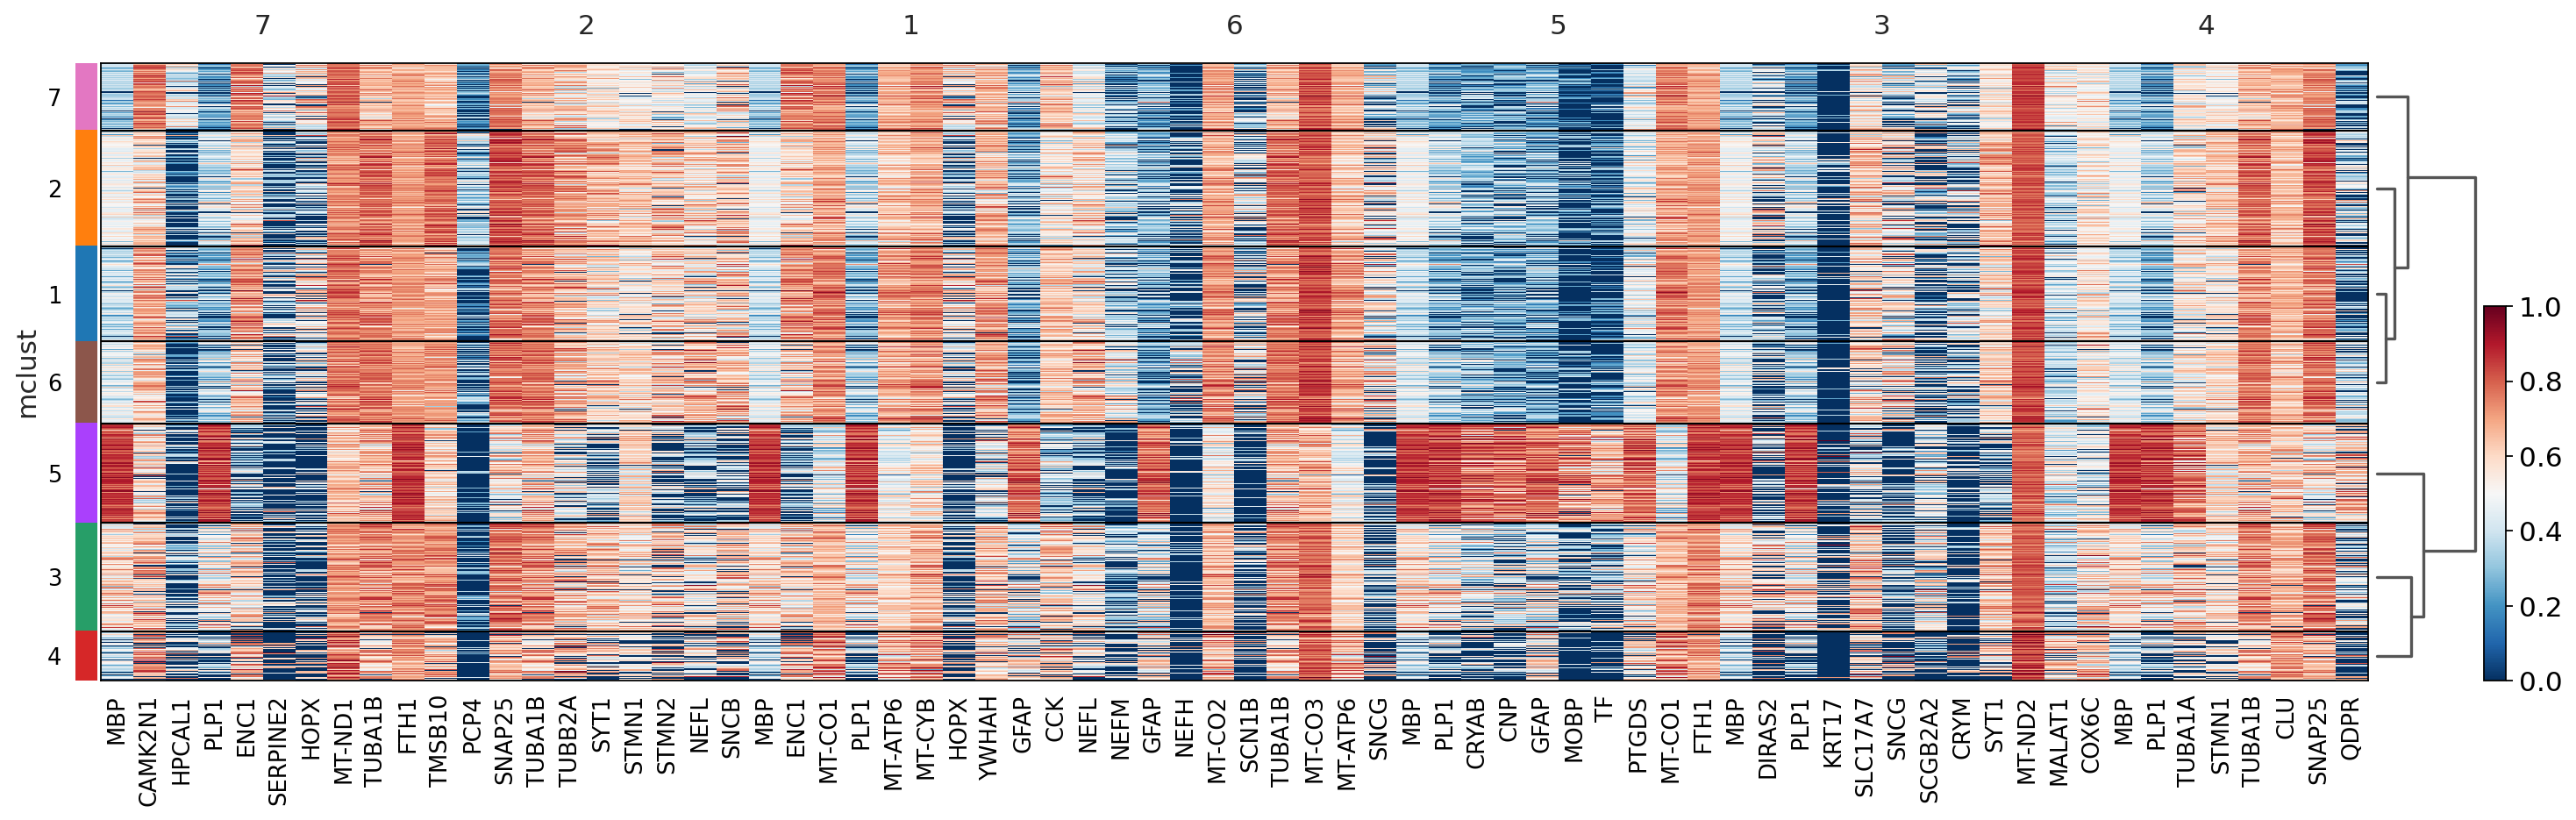

In [7]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=10, groupby='mclust',
                                standard_scale='var', cmap='RdBu_r',
                                show_gene_labels=True, save='_F_heatmap.png')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:07)


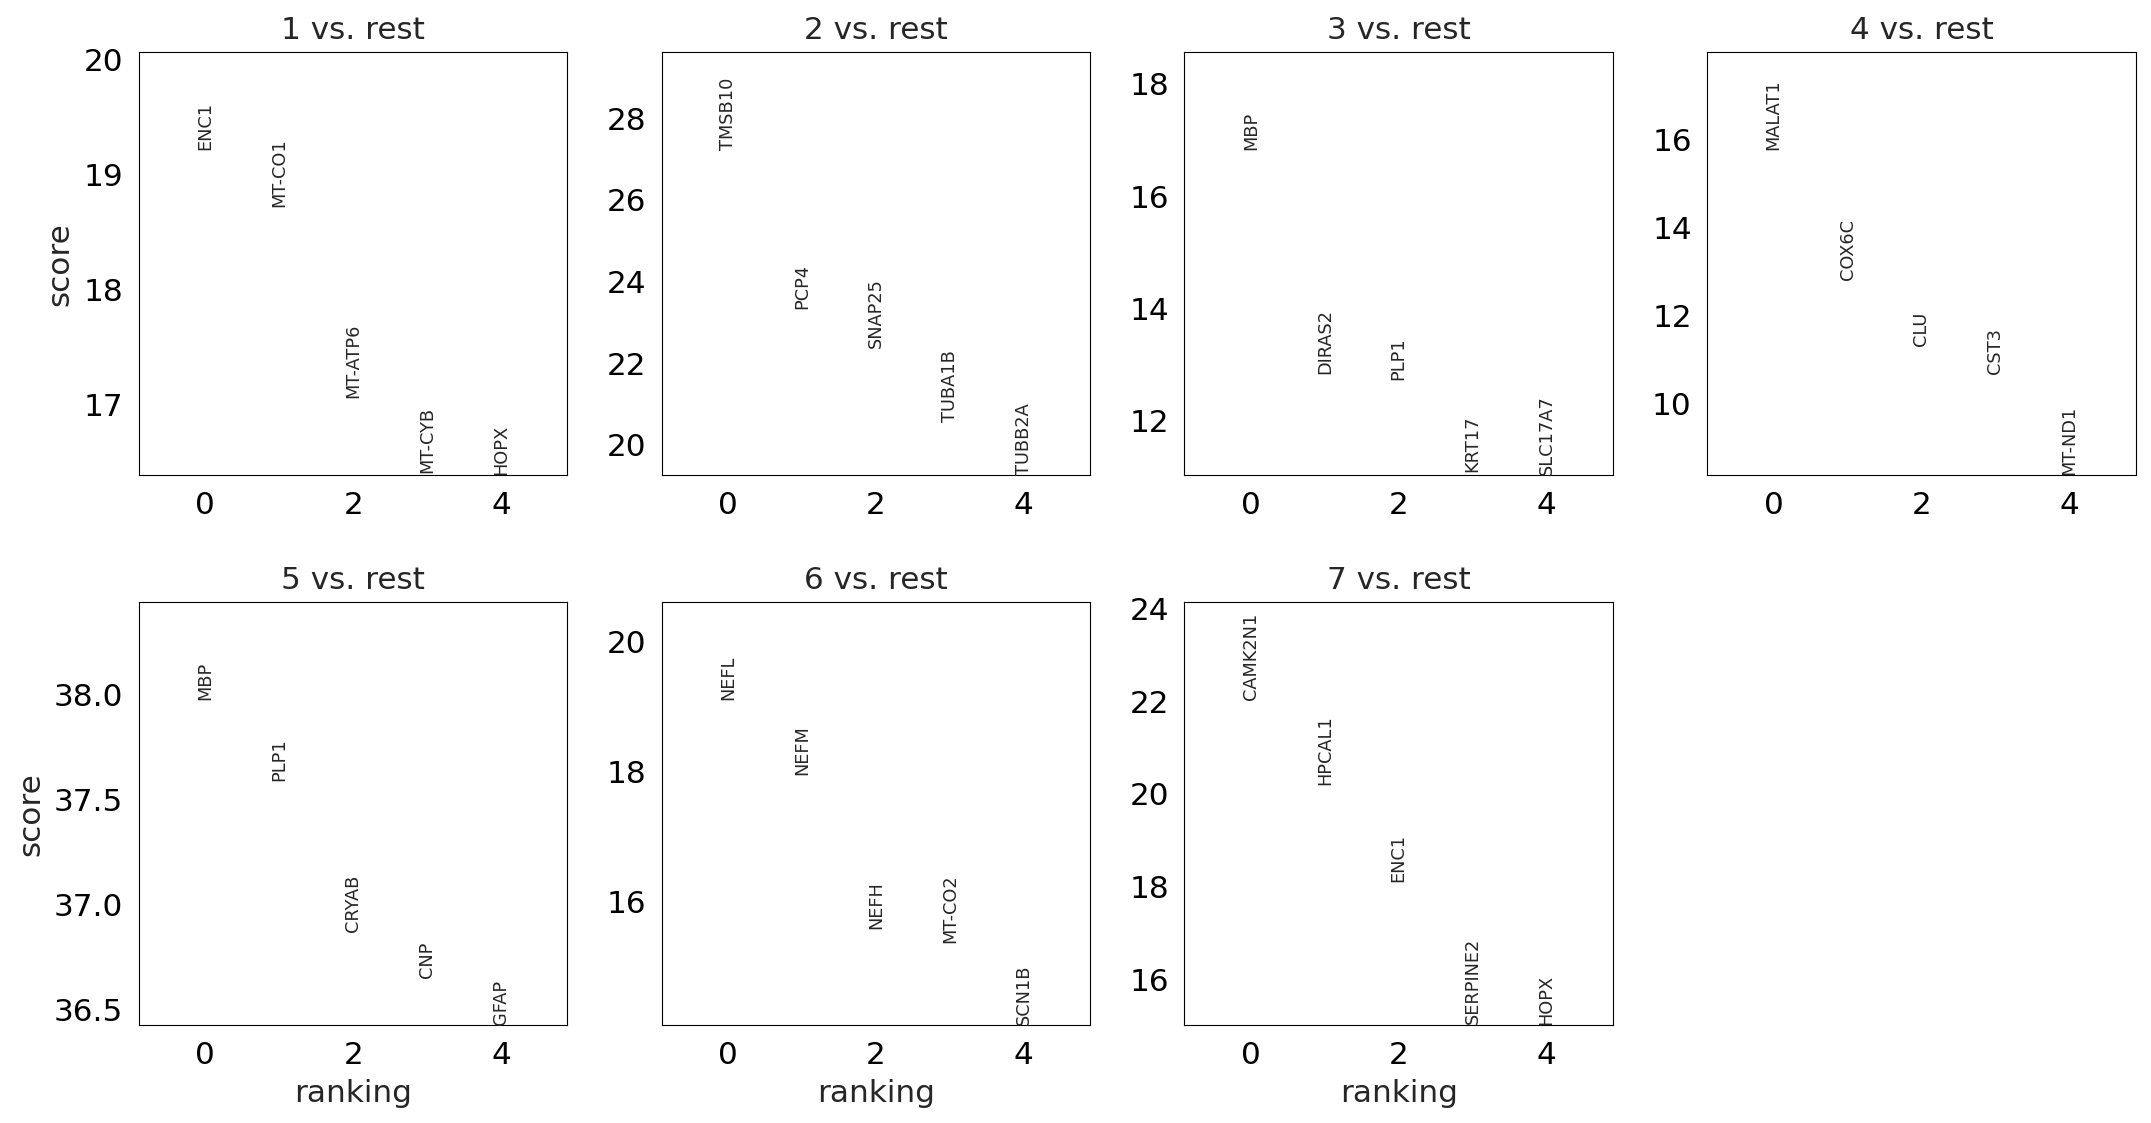

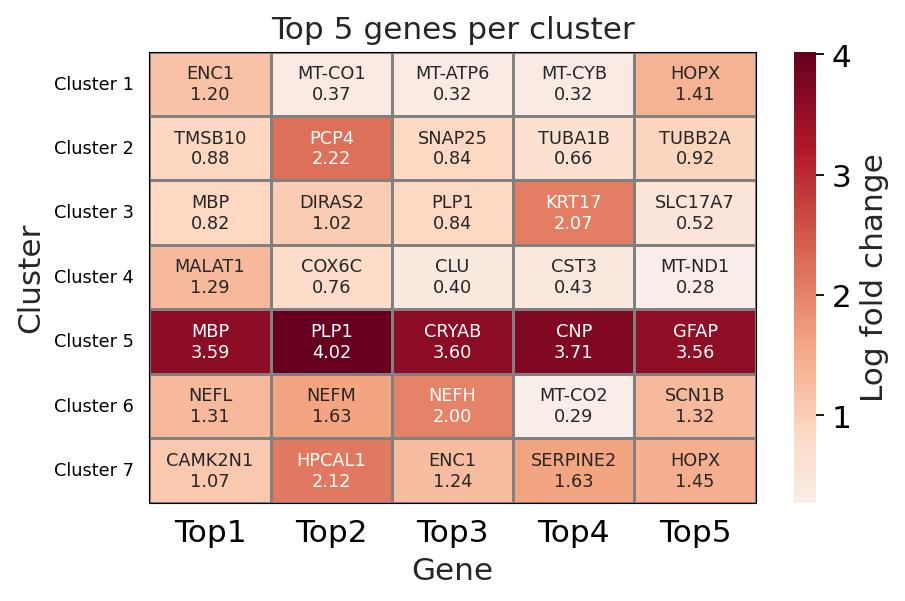

点图已保存至: /home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/151673/rank_genes_groups_top5.png
热图已保存至: /home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/151673/rank_genes_groups_logfoldchanges_heatmap.png


In [8]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

# ========== 1. 计算差异表达基因 ==========
adata_copy = adata.copy()
sc.tl.rank_genes_groups(adata_copy, groupby='mclust', method='wilcoxon',
                        use_raw=False, rankby_abs=False)

# ========== 2. 绘制并保存 score 点图（保留您的原逻辑） ==========
sc.pl.rank_genes_groups(adata_copy, n_genes=5, sharey=False, show=False)
fig = plt.gcf()
for ax in fig.get_axes():
    ax.set_facecolor('white')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)
    ax.set_xticks([0, 2, 4])
    ax.set_xticklabels(['0', '2', '4'])
fig.savefig(os.path.join(out_path, 'rank_genes_groups_top5.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ========== 3. 提取与点图一致的基因顺序及 logFC，绘制热图 ==========
# 直接从 rank_genes_groups 结果中获取基因顺序（与点图完全一致）
clusters = sorted(adata_copy.obs['mclust'].unique())
n_top = 5

# 从 adata.uns 中读取排序的基因名称
rank_names = adata_copy.uns['rank_genes_groups']['names']
rank_scores = adata_copy.uns['rank_genes_groups']['scores']   # 若有需要可不用
rank_logfc = adata_copy.uns['rank_genes_groups']['logfoldchanges']  # 所有簇的 logFC

# 构建热图数据（行=簇，列=Top1~Top5）
genes_matrix = []   # 存储基因名（用于显示）
logfc_matrix = []   # 存储 logFC 数值

for cluster in clusters:
    # 取出该簇的基因名（按分数排序，即点图顺序）
    genes = rank_names[cluster][:n_top]  # 前5个
    logfcs = rank_logfc[cluster][:n_top] # 对应的 logFC
    genes_matrix.append(genes)
    logfc_matrix.append(logfcs)

# 转换为 DataFrame
rank_labels = [f'Top{i+1}' for i in range(n_top)]
cluster_labels = [f'Cluster {c}' for c in clusters]
heatmap_df = pd.DataFrame(logfc_matrix, index=cluster_labels, columns=rank_labels)
# 注释矩阵：显示基因名 + 数值（例如 "Gene\n1.23"）
annot_matrix = pd.DataFrame(index=cluster_labels, columns=rank_labels, dtype=str)
for i, cluster in enumerate(clusters):
    for j in range(n_top):
        gene = genes_matrix[i][j]
        val = logfc_matrix[i][j]
        annot_matrix.iloc[i, j] = f"{gene}\n{val:.2f}"   # 保留两位小数

# 绘制热图
fig2, ax2 = plt.subplots(figsize=(6, 4))
sns.heatmap(
    heatmap_df,
    annot=annot_matrix,
    fmt='',
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Log fold change'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax2,
    annot_kws={'size': 8, 'ha': 'center', 'va': 'center'}
)
ax2.set_title('Top 5 genes per cluster')
ax2.set_ylabel('Cluster')
ax2.set_xlabel('Gene')
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=8)

# 设置样式：白底、无网格、黑色边框
ax2.set_facecolor('white')
ax2.grid(False)
for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.savefig(os.path.join(out_path, 'rank_genes_groups_logfoldchanges_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig2)

print("点图已保存至:", os.path.join(out_path, 'rank_genes_groups_top5.png'))
print("热图已保存至:", os.path.join(out_path, 'rank_genes_groups_logfoldchanges_heatmap.png'))

In [9]:
from PIL import Image

# 读取已保存的两张图片
img1_path = os.path.join(out_path, 'rank_genes_groups_top5.png')
img2_path = os.path.join(out_path, 'rank_genes_groups_logfoldchanges_heatmap.png')
img1 = Image.open(img1_path)
img2 = Image.open(img2_path)

# 获取原始尺寸
w1, h1 = img1.size
w2, h2 = img2.size

# 统一高度（取两者较大值，等比缩放宽度，保持比例）
new_h = max(h1, h2)
new_w1 = int(w1 * new_h / h1)
new_w2 = int(w2 * new_h / h2)
img1_resized = img1.resize((new_w1, new_h), Image.Resampling.LANCZOS)
img2_resized = img2.resize((new_w2, new_h), Image.Resampling.LANCZOS)

# 创建新画布并粘贴
combined = Image.new('RGB', (new_w1 + new_w2, new_h))
combined.paste(img1_resized, (0, 0))
combined.paste(img2_resized, (new_w1, 0))

# 保存组合图（保持300 DPI）
combined.save(os.path.join(out_path, 'combined_score_heatmap.png'), dpi=(300, 300))
print("组合图已保存至:", os.path.join(out_path, 'combined_score_heatmap.png'))

组合图已保存至: /home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/151673/combined_score_heatmap.png
